# 04 Parametric OLS Feature Selection

This notebook develops optimized parametric Ordinary Least Squares (OLS) regression models for **Heating Load** and **Cooling Load**. Unlike the previous baseline OLS notebook, this stage applies **forward selection** and **backward elimination** to identify a more parsimonious set of predictors before conducting full model assumption diagnostics.

## Modeling Strategy

The baseline OLS model used all available predictors and served as a benchmark. In this notebook, the goal is to build more refined parametric OLS models by selecting predictors using AIC-based forward and backward search. The selected models are then evaluated using train/test performance metrics and checked against the main OLS assumptions.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import shapiro

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
# ============================================================
# 2. LOAD SAVED TRAINING AND TESTING DATASETS
# ============================================================

DATA_DIR = Path("../data/modeling")

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")

y_heat_train = pd.read_csv(DATA_DIR / "y_heat_train.csv")["heating_load"]
y_heat_test = pd.read_csv(DATA_DIR / "y_heat_test.csv")["heating_load"]

y_cool_train = pd.read_csv(DATA_DIR / "y_cool_train.csv")["cooling_load"]
y_cool_test = pd.read_csv(DATA_DIR / "y_cool_test.csv")["cooling_load"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Heating train shape:", y_heat_train.shape)
print("Cooling train shape:", y_cool_train.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
Heating train shape: (614,)
Cooling train shape: (614,)


## Feature Encoding

The categorical predictors `orientation` and `glazing_area_distribution` are converted into dummy variables. This is necessary because `statsmodels` OLS requires a fully numeric design matrix. The same encoded feature structure is enforced on both training and testing datasets to ensure valid model evaluation.

In [3]:
# ============================================================
# 3. ENCODE CATEGORICAL VARIABLES
# ============================================================

X_train_encoded = pd.get_dummies(X_train, drop_first=True).astype(float)
X_test_encoded = pd.get_dummies(X_test, drop_first=True).astype(float)

# Ensure test set has exactly the same encoded columns as training set
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

display(X_train_encoded.head())

Encoded training shape: (614, 8)
Encoded testing shape: (154, 8)


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution
0,0.82,612.5,318.5,147.0,7.0,2.0,0.10,1.0
1,0.64,784.0,343.0,220.5,3.5,4.0,0.40,2.0
2,0.86,588.0,294.0,147.0,7.0,4.0,0.25,2.0
3,0.90,563.5,318.5,122.5,7.0,4.0,0.25,1.0
4,0.66,759.5,318.5,220.5,3.5,5.0,0.10,4.0


In [4]:
# ============================================================
# 4. EVALUATION FUNCTION
# ============================================================

def adjusted_r2_score(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


def evaluate_ols_model(model, X_train_selected, X_test_selected, y_train, y_test, target_name, model_name):
    X_train_sm = sm.add_constant(X_train_selected, has_constant="add")
    X_test_sm = sm.add_constant(X_test_selected, has_constant="add")

    train_pred = model.predict(X_train_sm)
    test_pred = model.predict(X_test_sm)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    n_train = X_train_selected.shape[0]
    n_test = X_test_selected.shape[0]
    p = X_train_selected.shape[1]

    results = pd.DataFrame({
        "Target": [target_name],
        "Model": [model_name],
        "No_of_Features": [p],
        "Train_R2": [train_r2],
        "Train_Adjusted_R2": [adjusted_r2_score(train_r2, n_train, p)],
        "Test_R2": [test_r2],
        "Test_Adjusted_R2": [adjusted_r2_score(test_r2, n_test, p)],
        "Test_RMSE": [np.sqrt(mean_squared_error(y_test, test_pred))],
        "Test_MAE": [mean_absolute_error(y_test, test_pred)],
        "Test_MAPE_percent": [np.mean(np.abs((y_test - test_pred) / y_test)) * 100],
        "AIC": [model.aic],
        "BIC": [model.bic]
    })

    return results, train_pred, test_pred

## Forward Selection and Backward Elimination

Forward selection starts with no predictors and adds one feature at a time when it improves model AIC. Backward elimination starts with all predictors and removes features when doing so improves model AIC. AIC is used because it balances model fit against model complexity.

In [5]:
# ============================================================
# 5. FORWARD SELECTION USING AIC
# ============================================================

def forward_selection_aic(X, y, verbose=True):
    remaining_features = list(X.columns)
    selected_features = []
    current_aic = np.inf
    selection_history = []

    while remaining_features:
        candidate_results = []

        for feature in remaining_features:
            candidate_features = selected_features + [feature]
            X_candidate = sm.add_constant(X[candidate_features], has_constant="add")
            model = sm.OLS(y, X_candidate).fit()
            candidate_results.append((model.aic, feature))

        candidate_results.sort(key=lambda x: x[0])
        best_aic, best_feature = candidate_results[0]

        if best_aic < current_aic:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            current_aic = best_aic
            selection_history.append({"Step": len(selected_features), "Action": "Add", "Feature": best_feature, "AIC": current_aic})
            if verbose:
                print(f"Step {len(selected_features)}: Added {best_feature}, AIC = {current_aic:.4f}")
        else:
            break

    final_model = sm.OLS(y, sm.add_constant(X[selected_features], has_constant="add")).fit()
    return selected_features, final_model, pd.DataFrame(selection_history)

In [6]:
# ============================================================
# 6. BACKWARD ELIMINATION USING AIC
# ============================================================

def backward_elimination_aic(X, y, verbose=True):
    selected_features = list(X.columns)
    current_model = sm.OLS(y, sm.add_constant(X[selected_features], has_constant="add")).fit()
    current_aic = current_model.aic
    selection_history = [{"Step": 0, "Action": "Start", "Feature": "All features", "AIC": current_aic}]
    step = 0

    while len(selected_features) > 1:
        candidate_results = []

        for feature in selected_features:
            candidate_features = [f for f in selected_features if f != feature]
            model = sm.OLS(y, sm.add_constant(X[candidate_features], has_constant="add")).fit()
            candidate_results.append((model.aic, feature, candidate_features))

        candidate_results.sort(key=lambda x: x[0])
        best_aic, feature_to_remove, best_features = candidate_results[0]

        if best_aic < current_aic:
            step += 1
            selected_features = best_features
            current_aic = best_aic
            selection_history.append({"Step": step, "Action": "Remove", "Feature": feature_to_remove, "AIC": current_aic})
            if verbose:
                print(f"Step {step}: Removed {feature_to_remove}, AIC = {current_aic:.4f}")
        else:
            break

    final_model = sm.OLS(y, sm.add_constant(X[selected_features], has_constant="add")).fit()
    return selected_features, final_model, pd.DataFrame(selection_history)

# Heating Load Parametric OLS Model

This section applies forward selection and backward elimination to identify an optimized parametric OLS model for Heating Load.

In [7]:
# ============================================================
# 7. HEATING LOAD: FORWARD SELECTION
# ============================================================

heat_forward_features, heat_forward_model, heat_forward_history = forward_selection_aic(
    X_train_encoded,
    y_heat_train,
    verbose=True
)

display(heat_forward_history)
print("Selected features from forward selection:")
print(heat_forward_features)
print("Forward AIC:", round(heat_forward_model.aic, 4))

Step 1: Added overall_height, AIC = 3619.6983
Step 2: Added glazing_area, AIC = 3351.8428
Step 3: Added wall_area, AIC = 3096.6422
Step 4: Added relative_compactness, AIC = 3084.5410
Step 5: Added roof_area, AIC = 3066.5657
Step 6: Added glazing_area_distribution, AIC = 3061.0985


,Step,Action,Feature,AIC
0,1,Add,overall_height,3619.698296
1,2,Add,glazing_area,3351.842802
2,3,Add,wall_area,3096.642200
3,4,Add,relative_compactness,3084.541023
4,5,Add,roof_area,3066.565700
5,6,Add,glazing_area_distribution,3061.098454


Selected features from forward selection:
['overall_height', 'glazing_area', 'wall_area', 'relative_compactness', 'roof_area', 'glazing_area_distribution']
Forward AIC: 3061.0985


In [8]:
# ============================================================
# 8. HEATING LOAD: BACKWARD ELIMINATION
# ============================================================

heat_backward_features, heat_backward_model, heat_backward_history = backward_elimination_aic(
    X_train_encoded,
    y_heat_train,
    verbose=True
)

display(heat_backward_history)
print("Selected features from backward elimination:")
print(heat_backward_features)
print("Backward AIC:", round(heat_backward_model.aic, 4))

Step 1: Removed orientation, AIC = 3061.0985


,Step,Action,Feature,AIC
0,0,Start,All features,3063.004003
1,1,Remove,orientation,3061.098454


Selected features from backward elimination:
['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'glazing_area', 'glazing_area_distribution']
Backward AIC: 3061.0985


In [9]:
# ============================================================
# 9. SELECT BEST HEATING LOAD PARAMETRIC MODEL
# ============================================================

if heat_forward_model.aic <= heat_backward_model.aic:
    heating_parametric_model = heat_forward_model
    heating_selected_features = heat_forward_features
    heating_selection_method = "Forward Selection"
else:
    heating_parametric_model = heat_backward_model
    heating_selected_features = heat_backward_features
    heating_selection_method = "Backward Elimination"

print("Best Heating Load selection method:", heating_selection_method)
print("Selected features:")
print(heating_selected_features)
print("Selected model AIC:", round(heating_parametric_model.aic, 4))
print("Selected model BIC:", round(heating_parametric_model.bic, 4))

print(heating_parametric_model.summary())

Best Heating Load selection method: Forward Selection
Selected features:
['overall_height', 'glazing_area', 'wall_area', 'relative_compactness', 'roof_area', 'glazing_area_distribution']
Selected model AIC: 3061.0985
Selected model BIC: 3092.0384
                            OLS Regression Results                            
Dep. Variable:           heating_load   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     1118.
Date:                Sun, 31 May 2026   Prob (F-statistic):          4.94e-324
Time:                        01:12:12   Log-Likelihood:                -1523.5
No. Observations:                 614   AIC:                             3061.
Df Residuals:                     607   BIC:                             3092.
Df Model:                           6                                         
Covariance Type:            nonrobust     

### Heating Load Parametric OLS Model Summary

The forward selection procedure identified a six-variable model consisting of **Overall Height, Glazing Area, Wall Area, Relative Compactness, Roof Area, and Glazing Area Distribution** as the optimal predictor set for Heating Load. The model achieved an **R² of 0.917** and an **Adjusted R² of 0.916**, indicating that approximately 91.7% of the variability in heating demand is explained by the selected building characteristics, while maintaining a relatively parsimonious structure compared to the baseline model. Most predictors were statistically significant at the 5% level, with **Glazing Area** and **Overall Height** exhibiting particularly strong effects on heating load, whereas **Wall Area** was not statistically significant (\(p = 0.111\)) and may contribute limited additional explanatory power.

The overall model was highly significant (\(F = 1118\), \(p < 0.001\)), confirming that the selected predictors collectively provide substantial explanatory capability. However, the large condition number (\(7.48 \times 10^4\)) suggests that multicollinearity may still be present despite the feature selection process. Additionally, the significant Omnibus and Jarque-Bera tests indicate departures from normality in the residuals, implying that some OLS assumptions may remain violated and should be further evaluated through the diagnostic tests performed in subsequent sections.

In [10]:
# ============================================================
# 10. HEATING LOAD MODEL PERFORMANCE
# ============================================================

heat_param_results, heat_param_train_pred, heat_param_test_pred = evaluate_ols_model(
    heating_parametric_model,
    X_train_encoded[heating_selected_features],
    X_test_encoded[heating_selected_features],
    y_heat_train,
    y_heat_test,
    target_name="Heating Load",
    model_name=f"Parametric OLS ({heating_selection_method})"
)

display(heat_param_results)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC
0,Heating Load,Parametric OLS (Forward Selection),6,0.917052,0.916232,0.912213,0.90863,3.024936,2.184008,10.272485,3061.098454,3092.038419


# Cooling Load Parametric OLS Model

This section applies the same forward and backward feature selection procedures to build an optimized parametric OLS model for Cooling Load.

In [11]:
# ============================================================
# 11. COOLING LOAD: FORWARD SELECTION
# ============================================================

cool_forward_features, cool_forward_model, cool_forward_history = forward_selection_aic(
    X_train_encoded,
    y_cool_train,
    verbose=True
)

display(cool_forward_history)
print("Selected features from forward selection:")
print(cool_forward_features)
print("Forward AIC:", round(cool_forward_model.aic, 4))

Step 1: Added overall_height, AIC = 3516.0649
Step 2: Added glazing_area, AIC = 3365.4403
Step 3: Added relative_compactness, AIC = 3214.1615
Step 4: Added roof_area, AIC = 3188.4379
Step 5: Added surface_area, AIC = 3182.4808


,Step,Action,Feature,AIC
0,1,Add,overall_height,3516.064881
1,2,Add,glazing_area,3365.440326
2,3,Add,relative_compactness,3214.161489
3,4,Add,roof_area,3188.437888
4,5,Add,surface_area,3182.480788


Selected features from forward selection:
['overall_height', 'glazing_area', 'relative_compactness', 'roof_area', 'surface_area']
Forward AIC: 3182.4808


In [12]:
# ============================================================
# 12. COOLING LOAD: BACKWARD ELIMINATION
# ============================================================

cool_backward_features, cool_backward_model, cool_backward_history = backward_elimination_aic(
    X_train_encoded,
    y_cool_train,
    verbose=True
)

display(cool_backward_history)
print("Selected features from backward elimination:")
print(cool_backward_features)
print("Backward AIC:", round(cool_backward_model.aic, 4))

Step 1: Removed glazing_area_distribution, AIC = 3184.2556
Step 2: Removed orientation, AIC = 3182.4808
Step 3: Removed wall_area, AIC = 3182.4808


,Step,Action,Feature,AIC
0,0,Start,All features,3186.098387
1,1,Remove,glazing_area_distribution,3184.255573
2,2,Remove,orientation,3182.480788
3,3,Remove,wall_area,3182.480788


Selected features from backward elimination:
['relative_compactness', 'surface_area', 'roof_area', 'overall_height', 'glazing_area']
Backward AIC: 3182.4808


In [13]:
# ============================================================
# 13. SELECT BEST COOLING LOAD PARAMETRIC MODEL
# ============================================================

if cool_forward_model.aic <= cool_backward_model.aic:
    cooling_parametric_model = cool_forward_model
    cooling_selected_features = cool_forward_features
    cooling_selection_method = "Forward Selection"
else:
    cooling_parametric_model = cool_backward_model
    cooling_selected_features = cool_backward_features
    cooling_selection_method = "Backward Elimination"

print("Best Cooling Load selection method:", cooling_selection_method)
print("Selected features:")
print(cooling_selected_features)
print("Selected model AIC:", round(cooling_parametric_model.aic, 4))
print("Selected model BIC:", round(cooling_parametric_model.bic, 4))

print(cooling_parametric_model.summary())

Best Cooling Load selection method: Forward Selection
Selected features:
['overall_height', 'glazing_area', 'relative_compactness', 'roof_area', 'surface_area']
Selected model AIC: 3182.4808
Selected model BIC: 3209.0008
                            OLS Regression Results                            
Dep. Variable:           cooling_load   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     943.7
Date:                Sun, 31 May 2026   Prob (F-statistic):          9.94e-284
Time:                        01:17:28   Log-Likelihood:                -1585.2
No. Observations:                 614   AIC:                             3182.
Df Residuals:                     608   BIC:                             3209.
Df Model:                           5                                         
Covariance Type:            nonrobust                               

### Cooling Load Parametric OLS Model Summary

The forward selection procedure identified a five-variable model consisting of **Overall Height, Glazing Area, Relative Compactness, Roof Area, and Surface Area** as the optimal predictor set for Cooling Load. The resulting model achieved an **R² of 0.886** and an **Adjusted R² of 0.885**, indicating that approximately 88.6% of the variability in cooling demand is explained by the selected building characteristics while maintaining a relatively parsimonious model structure. All selected predictors were statistically significant at the 5% significance level, suggesting that each variable contributes meaningful explanatory information to the prediction of cooling load.

The overall model was highly significant (\(F = 943.7\), \(p < 0.001\)), confirming strong collective predictive power of the selected features. However, the large condition number (\(1.43 \times 10^5\)) indicates that multicollinearity may still be present among the retained predictors despite the feature selection process. Furthermore, the significant Omnibus and Jarque-Bera tests suggest departures from residual normality, implying that some OLS assumptions may remain violated and should be carefully evaluated through the diagnostic analyses before relying on the model for statistical inference.

In [14]:
# ============================================================
# 14. COOLING LOAD MODEL PERFORMANCE
# ============================================================

cool_param_results, cool_param_train_pred, cool_param_test_pred = evaluate_ols_model(
    cooling_parametric_model,
    X_train_encoded[cooling_selected_features],
    X_test_encoded[cooling_selected_features],
    y_cool_train,
    y_cool_test,
    target_name="Cooling Load",
    model_name=f"Parametric OLS ({cooling_selection_method})"
)

display(cool_param_results)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC
0,Cooling Load,Parametric OLS (Forward Selection),5,0.88585,0.884911,0.89257,0.88894,3.155028,2.20121,8.496013,3182.480788,3209.000758


In [15]:
# ============================================================
# 15. PARAMETRIC MODEL COMPARISON TABLE
# ============================================================

parametric_results = pd.concat([heat_param_results, cool_param_results], ignore_index=True)
display(parametric_results)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC
0,Heating Load,Parametric OLS (Forward Selection),6,0.917052,0.916232,0.912213,0.90863,3.024936,2.184008,10.272485,3061.098454,3092.038419
1,Cooling Load,Parametric OLS (Forward Selection),5,0.885850,0.884911,0.892570,0.88894,3.155028,2.201210,8.496013,3182.480788,3209.000758


# Full Assumption Diagnostics for Selected Parametric OLS Models

The selected Heating Load and Cooling Load parametric OLS models are now subjected to full diagnostic assessment. The diagnostics cover linearity, residual normality, homoscedasticity, independence of errors, multicollinearity, influential observations, and model specification.

In [16]:
# ============================================================
# 16. ASSUMPTION DIAGNOSTIC FUNCTION
# ============================================================

def run_ols_diagnostics(model, X_selected, y_train, train_pred, target_name):
    residuals = y_train - train_pred

    print("=" * 80)
    print(f"{target_name.upper()} PARAMETRIC OLS DIAGNOSTICS")
    print("=" * 80)

    # Linearity: Residuals vs fitted values
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=train_pred, y=residuals)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title(f"{target_name}: Residuals vs Fitted Values")
    plt.tight_layout()
    plt.show()

    # Normality: Histogram
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, kde=True)
    plt.xlabel("Residuals")
    plt.title(f"{target_name}: Residual Distribution")
    plt.tight_layout()
    plt.show()

    # Normality: QQ Plot
    sm.qqplot(residuals, line="45")
    plt.title(f"{target_name}: Residual QQ Plot")
    plt.tight_layout()
    plt.show()

    # Formal assumption tests
    shapiro_stat, shapiro_p = shapiro(residuals)
    bp = het_breuschpagan(model.resid, model.model.exog)
    dw = durbin_watson(model.resid)
    reset = linear_reset(model, power=2, use_f=True)

    diagnostics_table = pd.DataFrame({
        "Assumption": ["Normality of residuals", "Homoscedasticity", "Independence of errors", "Model specification"],
        "Test": ["Shapiro-Wilk", "Breusch-Pagan", "Durbin-Watson", "Ramsey RESET"],
        "Statistic": [shapiro_stat, bp[0], dw, float(reset.fvalue)],
        "P_value": [shapiro_p, bp[1], np.nan, reset.pvalue],
        "Interpretation_Guide": [
            "p < 0.05 suggests non-normal residuals",
            "p < 0.05 suggests heteroscedasticity",
            "Value close to 2 suggests independence",
            "p < 0.05 suggests model misspecification"
        ]
    })

    display(diagnostics_table)

    # Multicollinearity: VIF
    vif_table = pd.DataFrame({
        "Variable": X_selected.columns,
        "VIF": [variance_inflation_factor(X_selected.values, i) for i in range(X_selected.shape[1])]
    }).sort_values("VIF", ascending=False)

    display(vif_table)

    # Influential observations: Cook's Distance
    influence = model.get_influence()
    cooks_d = influence.cooks_distance[0]
    threshold = 4 / len(cooks_d)

    plt.figure(figsize=(12, 6))
    plt.stem(range(len(cooks_d)), cooks_d)
    plt.axhline(threshold, color="red", linestyle="--", label=f"Threshold = {threshold:.4f}")

    for i, value in enumerate(cooks_d):
        if value > threshold:
            plt.annotate(str(i), xy=(i, value), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=8)

    plt.xlabel("Observation Index")
    plt.ylabel("Cook's Distance")
    plt.title(f"{target_name}: Cook's Distance")
    plt.legend()
    plt.tight_layout()
    plt.show()

    influential_obs = pd.DataFrame({
        "Observation_Index": np.where(cooks_d > threshold)[0],
        "Cooks_Distance": cooks_d[cooks_d > threshold]
    }).sort_values("Cooks_Distance", ascending=False)

    display(influential_obs)

    return diagnostics_table, vif_table, influential_obs

## Heating Load Parametric OLS Diagnostics

HEATING LOAD PARAMETRIC OLS DIAGNOSTICS


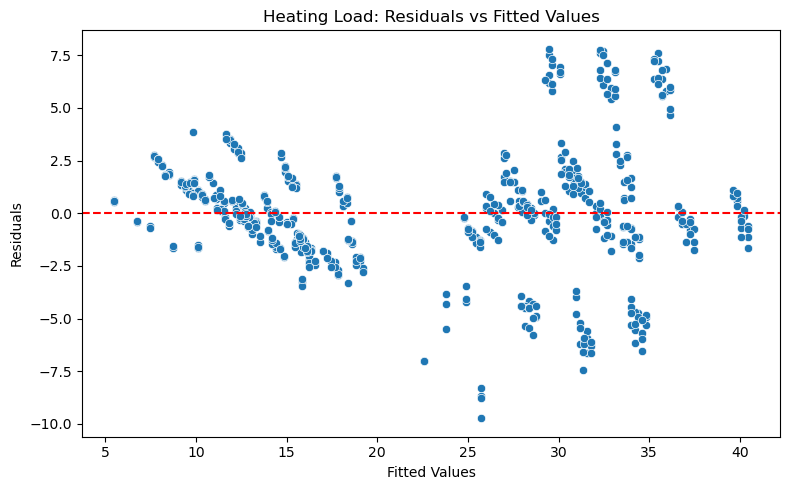

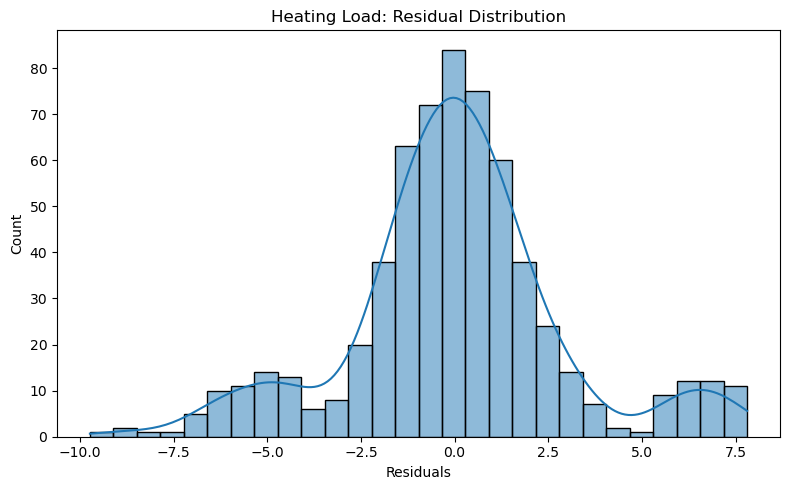

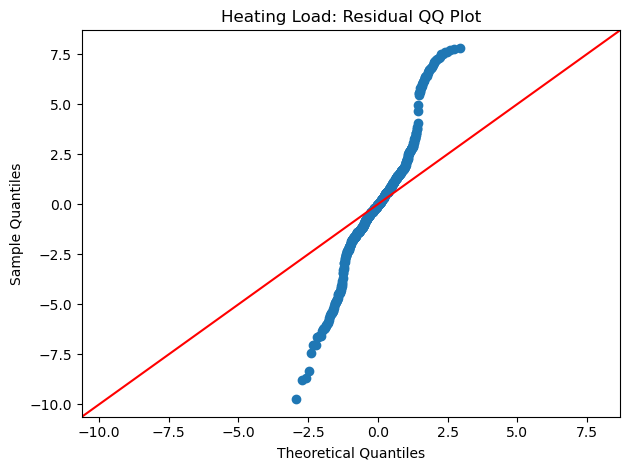

,Assumption,Test,Statistic,P_value,Interpretation_Guide
0,Normality of residuals,Shapiro-Wilk,0.954388,7.515132e-13,p < 0.05 suggests non-normal residuals
1,Homoscedasticity,Breusch-Pagan,239.943261,5.772311e-49,p < 0.05 suggests heteroscedasticity
2,Independence of errors,Durbin-Watson,1.882537,NaN,Value close to 2 suggests independence
3,Model specification,Ramsey RESET,52.375851,1.392856e-12,p < 0.05 suggests model misspecification


,Variable,VIF
3,relative_compactness,170.667499
0,overall_height,133.828682
2,wall_area,72.520341
4,roof_area,68.798519
5,glazing_area_distribution,4.449997
1,glazing_area,4.267004


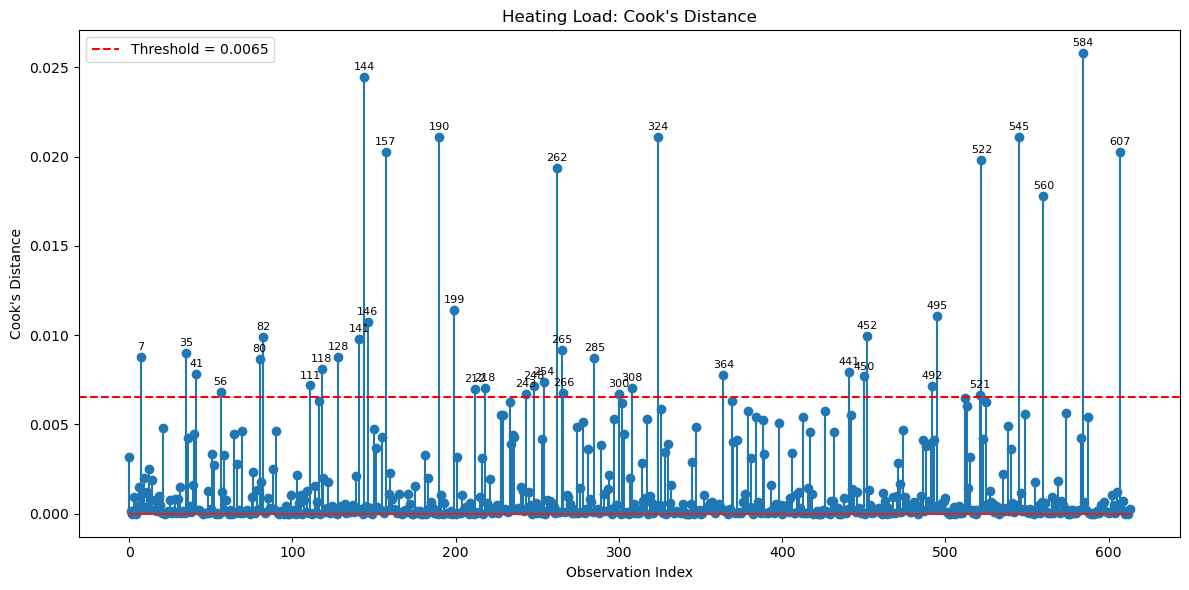

,Observation_Index,Cooks_Distance
37,584,0.025781
10,144,0.024438
26,324,0.021114
35,545,0.021114
13,190,0.021114
38,607,0.020277
12,157,0.020277
34,522,0.019811
20,262,0.019361
36,560,0.017786


In [17]:
# ============================================================
# 17. HEATING LOAD PARAMETRIC MODEL DIAGNOSTICS
# ============================================================

heat_diagnostics, heat_vif, heat_influential_obs = run_ols_diagnostics(
    model=heating_parametric_model,
    X_selected=X_train_encoded[heating_selected_features],
    y_train=y_heat_train,
    train_pred=heat_param_train_pred,
    target_name="Heating Load"
)

## Cooling Load Parametric OLS Diagnostics

COOLING LOAD PARAMETRIC OLS DIAGNOSTICS


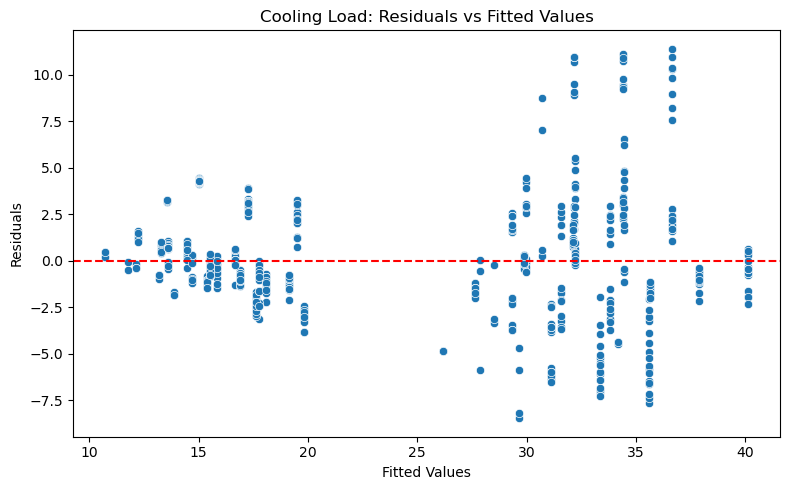

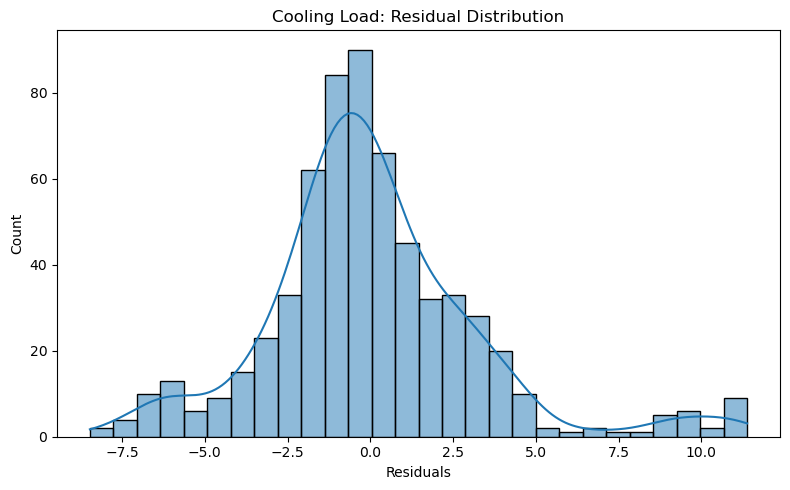

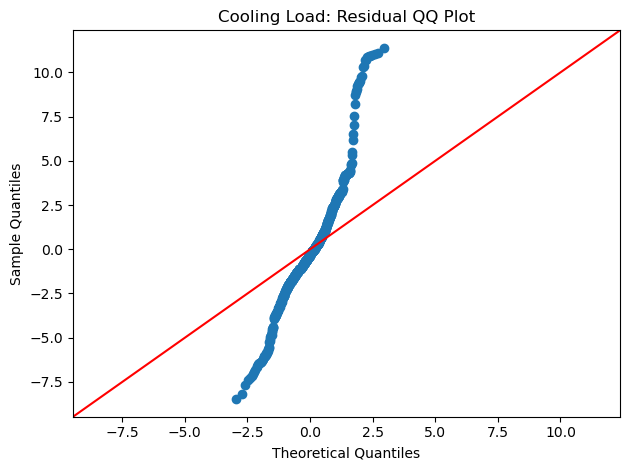

,Assumption,Test,Statistic,P_value,Interpretation_Guide
0,Normality of residuals,Shapiro-Wilk,0.936209,1.536209e-15,p < 0.05 suggests non-normal residuals
1,Homoscedasticity,Breusch-Pagan,170.332107,6.197877e-35,p < 0.05 suggests heteroscedasticity
2,Independence of errors,Durbin-Watson,1.932191,NaN,Value close to 2 suggests independence
3,Model specification,Ramsey RESET,18.108827,2.416333e-05,p < 0.05 suggests model misspecification


,Variable,VIF
4,surface_area,322.971541
3,roof_area,294.588279
2,relative_compactness,170.054047
0,overall_height,133.826930
1,glazing_area,4.083448


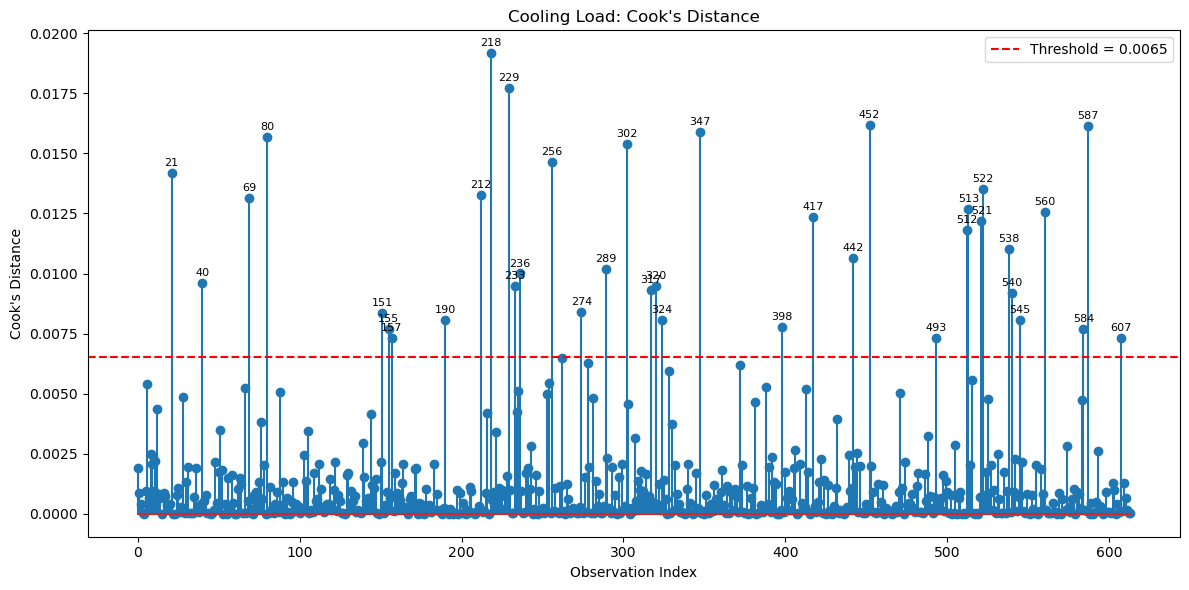

,Observation_Index,Cooks_Distance
9,218,0.019165
10,229,0.017712
24,452,0.016202
35,587,0.016143
20,347,0.015885
3,80,0.015671
16,302,0.015385
13,256,0.014652
0,21,0.014186
29,522,0.013510


In [18]:
# ============================================================
# 18. COOLING LOAD PARAMETRIC MODEL DIAGNOSTICS
# ============================================================

cool_diagnostics, cool_vif, cool_influential_obs = run_ols_diagnostics(
    model=cooling_parametric_model,
    X_selected=X_train_encoded[cooling_selected_features],
    y_train=y_cool_train,
    train_pred=cool_param_train_pred,
    target_name="Cooling Load"
)

# Save Parametric OLS Outputs

The selected features, performance metrics, and diagnostic outputs are saved for comparison with later modeling stages.

In [19]:
# ============================================================
# 19. SAVE PARAMETRIC MODEL OUTPUTS
# ============================================================

OUTPUT_DIR = Path("../outputs/models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

parametric_results.to_csv(OUTPUT_DIR / "parametric_ols_results.csv", index=False)
pd.DataFrame({"Selected_Feature": heating_selected_features}).to_csv(OUTPUT_DIR / "heating_parametric_selected_features.csv", index=False)
pd.DataFrame({"Selected_Feature": cooling_selected_features}).to_csv(OUTPUT_DIR / "cooling_parametric_selected_features.csv", index=False)
heat_diagnostics.to_csv(OUTPUT_DIR / "heating_parametric_diagnostics.csv", index=False)
cool_diagnostics.to_csv(OUTPUT_DIR / "cooling_parametric_diagnostics.csv", index=False)
heat_vif.to_csv(OUTPUT_DIR / "heating_parametric_vif.csv", index=False)
cool_vif.to_csv(OUTPUT_DIR / "cooling_parametric_vif.csv", index=False)

print("Parametric OLS outputs saved to:", OUTPUT_DIR.resolve())

Parametric OLS outputs saved to: C:\Users\admin\Desktop\pppp lab\group-work\outputs\models


# Overall Assessment of the Parametric OLS Models

The feature selection process successfully produced more parsimonious OLS models while maintaining strong predictive performance. The Heating Load model retained six predictors and achieved a test \(R^2\) of **0.912**, while the Cooling Load model retained five predictors and achieved a test \(R^2\) of **0.893**, demonstrating that the selected building characteristics explain a substantial proportion of the variability in both energy demand measures. The small differences between training and testing performance indicate that both models generalize well and show little evidence of severe overfitting.

From an explanatory perspective, the selected predictors are consistent with building physics, with **Overall Height**, **Glazing Area**, **Relative Compactness**, **Roof Area**, and other structural characteristics emerging as the most influential determinants of energy performance. Most retained variables were statistically significant at the 5% level, suggesting that the feature selection procedure successfully identified meaningful predictors while removing less informative variables.

However, the diagnostic analysis revealed that several important OLS assumptions remain violated. The Shapiro-Wilk tests indicate that residuals are not normally distributed for either model, while the Breusch-Pagan tests provide strong evidence of heteroscedasticity, implying that the variance of the residuals is not constant. In addition, the Ramsey RESET tests were highly significant for both models, suggesting that important nonlinear relationships or interaction effects are still not adequately captured by the linear specification.

The only assumption that was reasonably satisfied by both models was the independence of errors, as evidenced by Durbin-Watson statistics of approximately **1.88** for Heating Load and **1.93** for Cooling Load, both close to the ideal value of 2.0. Furthermore, the VIF analysis revealed severe multicollinearity among several geometric building characteristics, with extremely large VIF values and condition numbers, indicating substantial redundancy among predictors despite the feature selection process.

Overall, the parametric OLS models provide strong baseline predictive performance and valuable insight into the key determinants of building energy loads. Nevertheless, the persistent violations of normality, homoscedasticity, model specification, and multicollinearity assumptions suggest that linear regression may not fully capture the underlying complexity of the data. Consequently, the next phase of the analysis should focus on more advanced approaches, including **regularized regression methods (Ridge, LASSO, and Elastic Net)** to address multicollinearity, followed by **semi-parametric and nonlinear models** such as Generalized Additive Models (GAMs) and machine learning algorithms to better capture nonlinear relationships and potentially improve predictive accuracy.